# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Load Dataset

In [2]:
df = pd.read_csv('../datasets/Housing.csv')

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df.shape

(545, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
540    False
541    False
542    False
543    False
544    False
Length: 545, dtype: bool

In [8]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# EDA

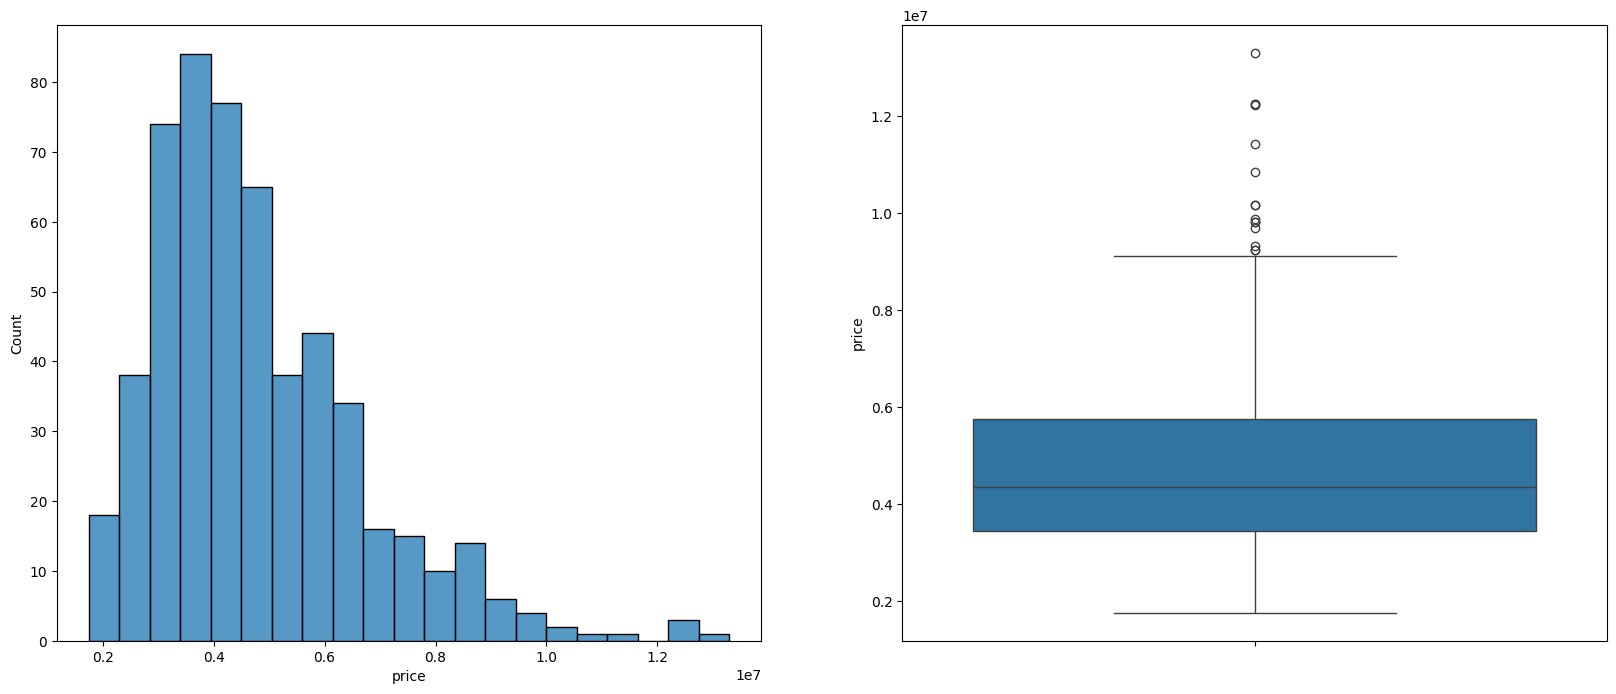

In [9]:
plt.figure(figsize=(20,8))

plt.subplot(1,2,1)
sns.histplot(
    x='price',
    data=df
)

plt.subplot(1,2,2)
sns.boxplot(
    y='price',
    data=df
)

plt.show()

In [10]:
arr = ['bedrooms','bathrooms','stories','mainroad','guestroom','basement','hotwaterheating','airconditioning','parking','prefarea', 'furnishingstatus']
for x in range(0, len(arr)):
    print(arr[x],": ", df[arr[x]].value_counts())

bedrooms :  bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64
bathrooms :  bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64
stories :  stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64
mainroad :  mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom :  guestroom
no     448
yes     97
Name: count, dtype: int64
basement :  basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating :  hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning :  airconditioning
no     373
yes    172
Name: count, dtype: int64
parking :  parking
0    299
1    126
2    108
3     12
Name: count, dtype: int64
prefarea :  prefarea
no     417
yes    128
Name: count, dtype: int64
furnishingstatus :  furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [23]:
categorical = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea', 'furnishingstatus']
numerical = ['area', 'price','bedrooms','bathrooms','stories','parking']

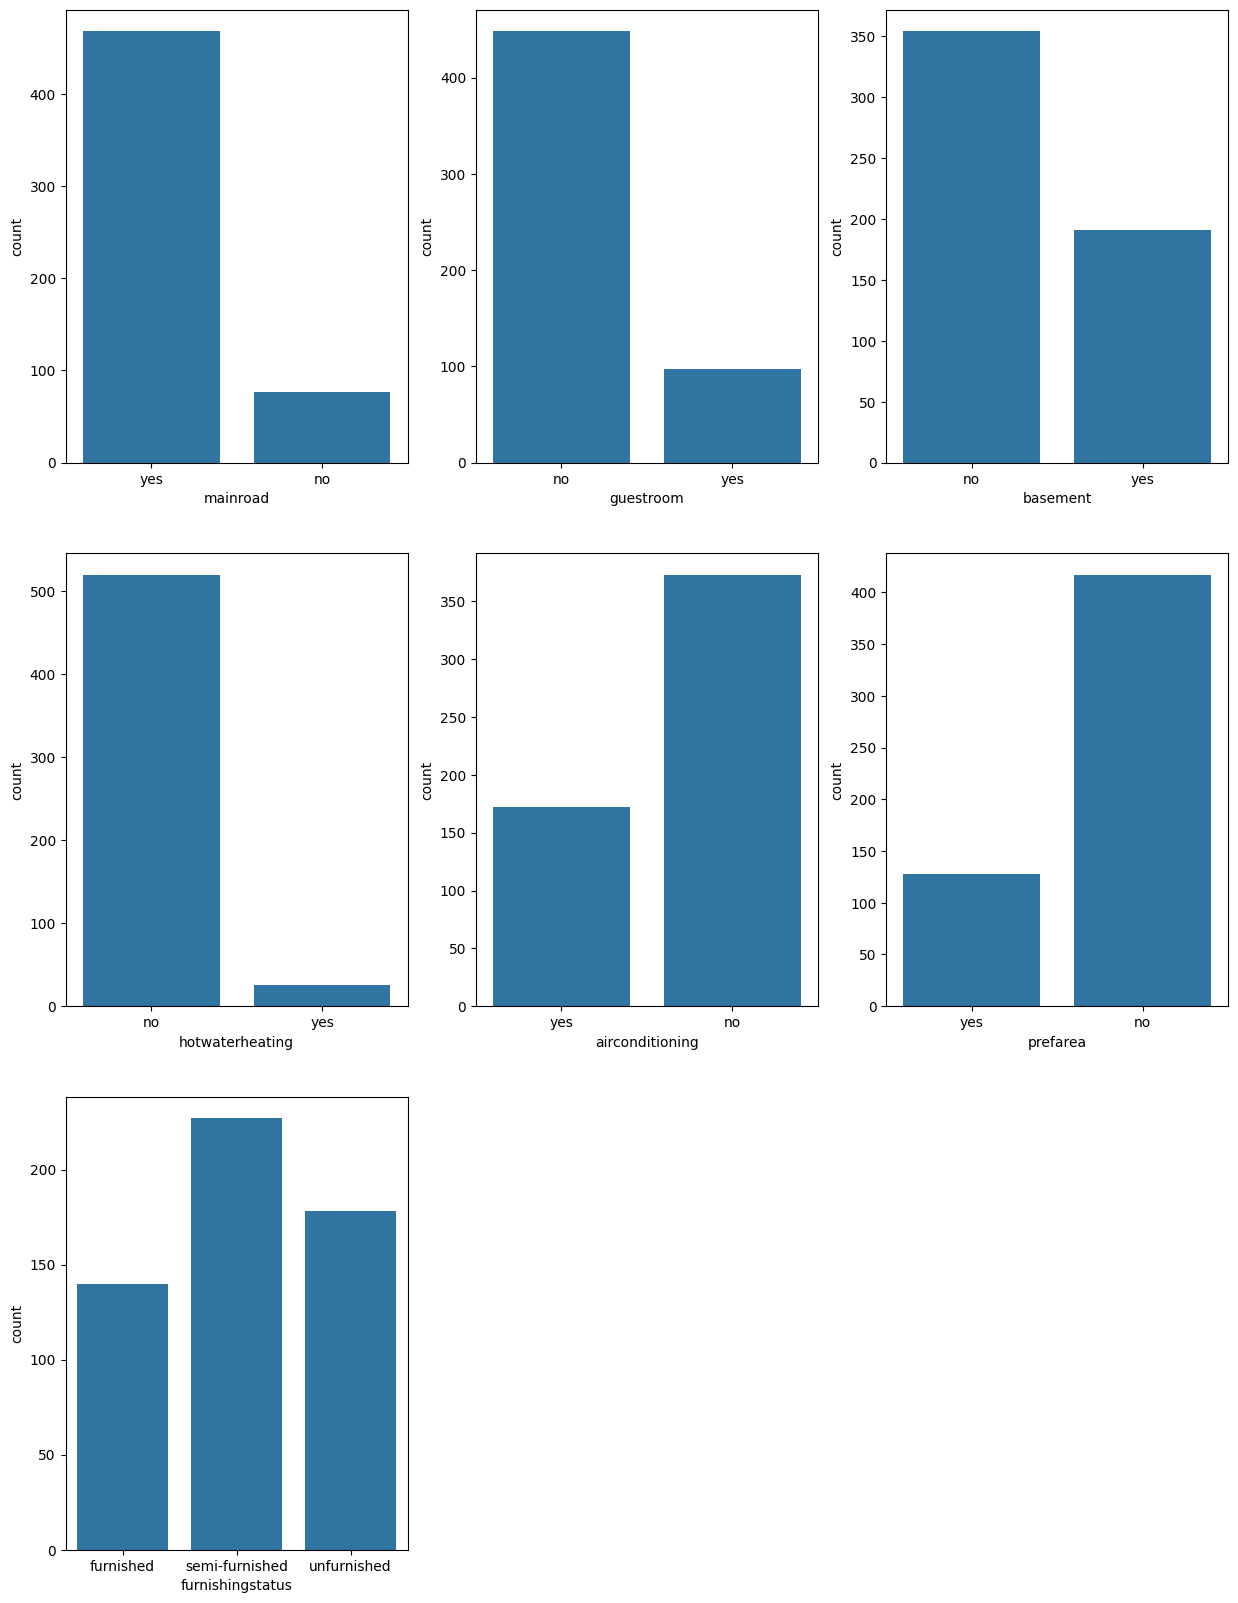

In [12]:
def countplot(column,fig_no):
    plt.subplot(3,3,fig_no)
    sns.countplot(
        x=column,
        data=df
    )

plt.figure(figsize=(15,20))
countplot('mainroad',1)
countplot('guestroom',2)
countplot('basement',3)
countplot('hotwaterheating',4)
countplot('airconditioning',5)
countplot('prefarea',6)
countplot('furnishingstatus',7)

plt.show()

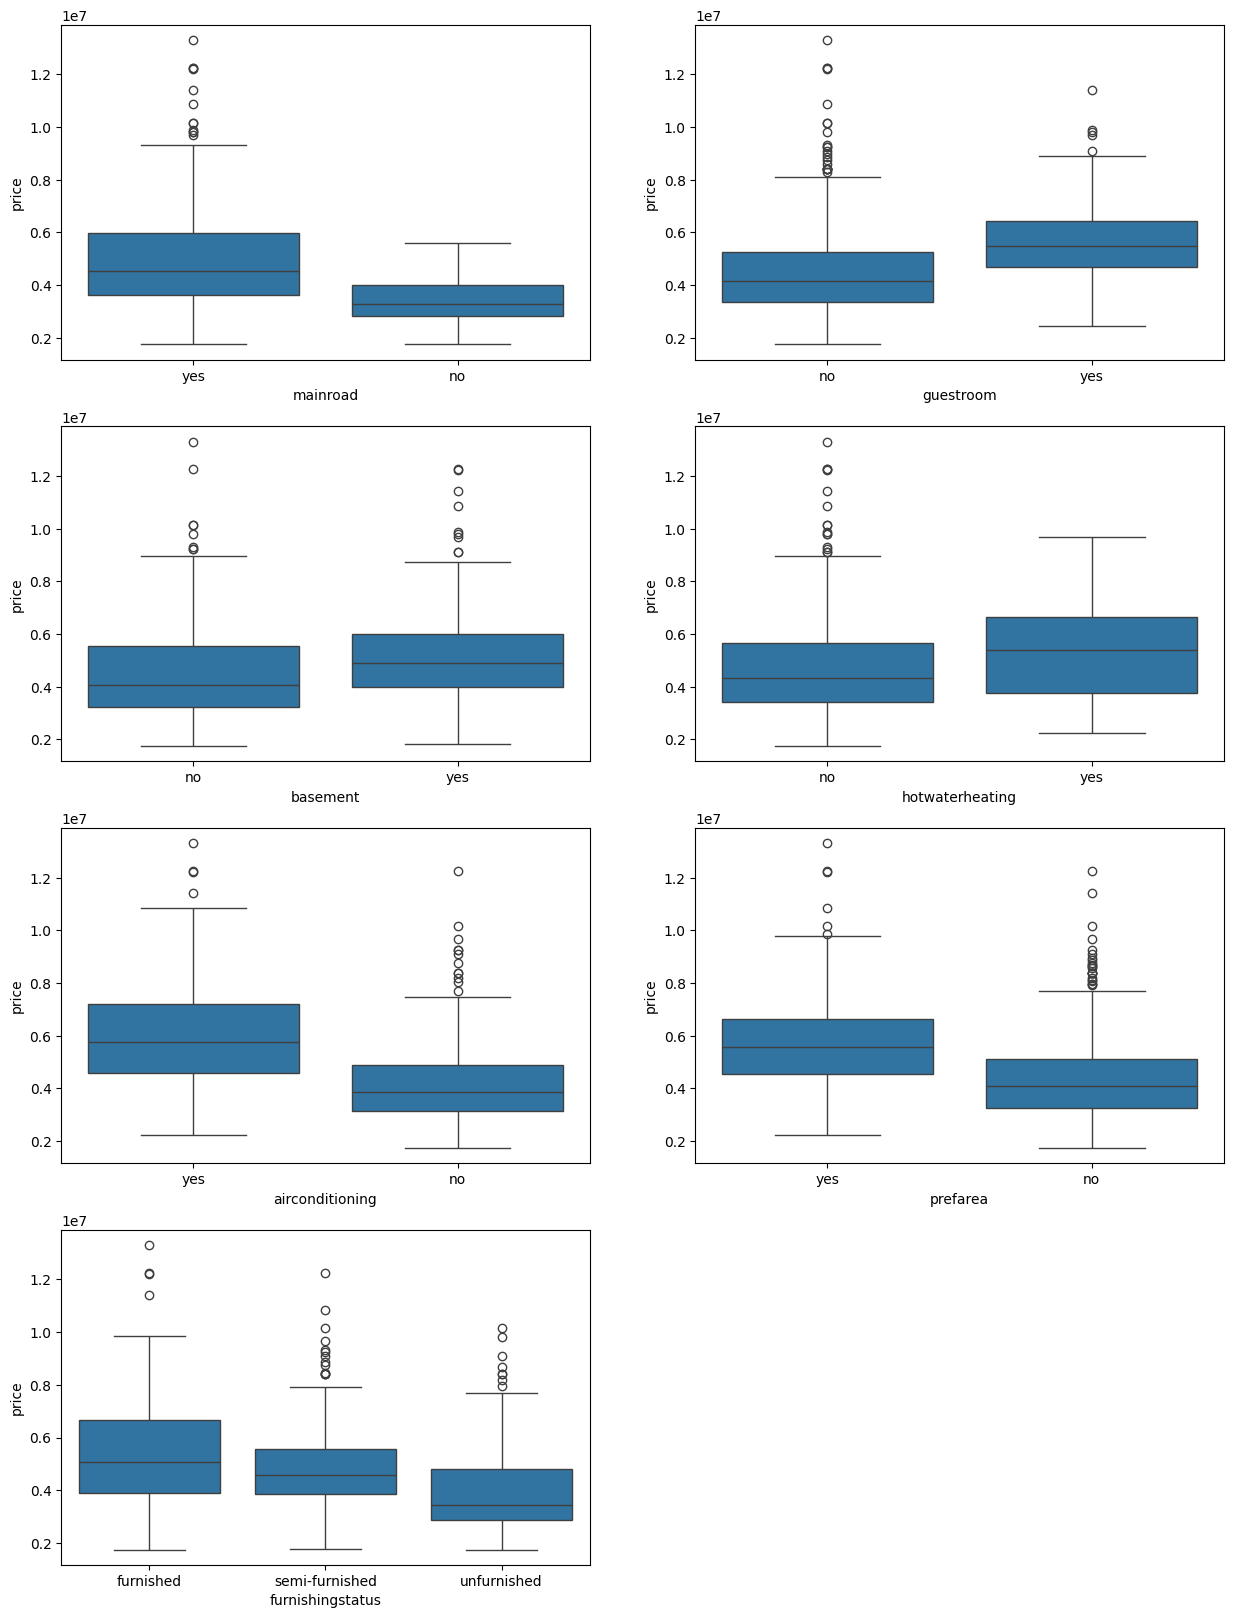

In [13]:
def boxplot(column,fig_no):
    plt.subplot(4,2,fig_no)
    sns.boxplot(
        x=column,
        y='price',
        data=df
    )

plt.figure(figsize=(15,20))
boxplot('mainroad',1)
boxplot('guestroom',2)
boxplot('basement',3)
boxplot('hotwaterheating',4)
boxplot('airconditioning',5)
boxplot('prefarea',6)
boxplot('furnishingstatus',7)

plt.show()

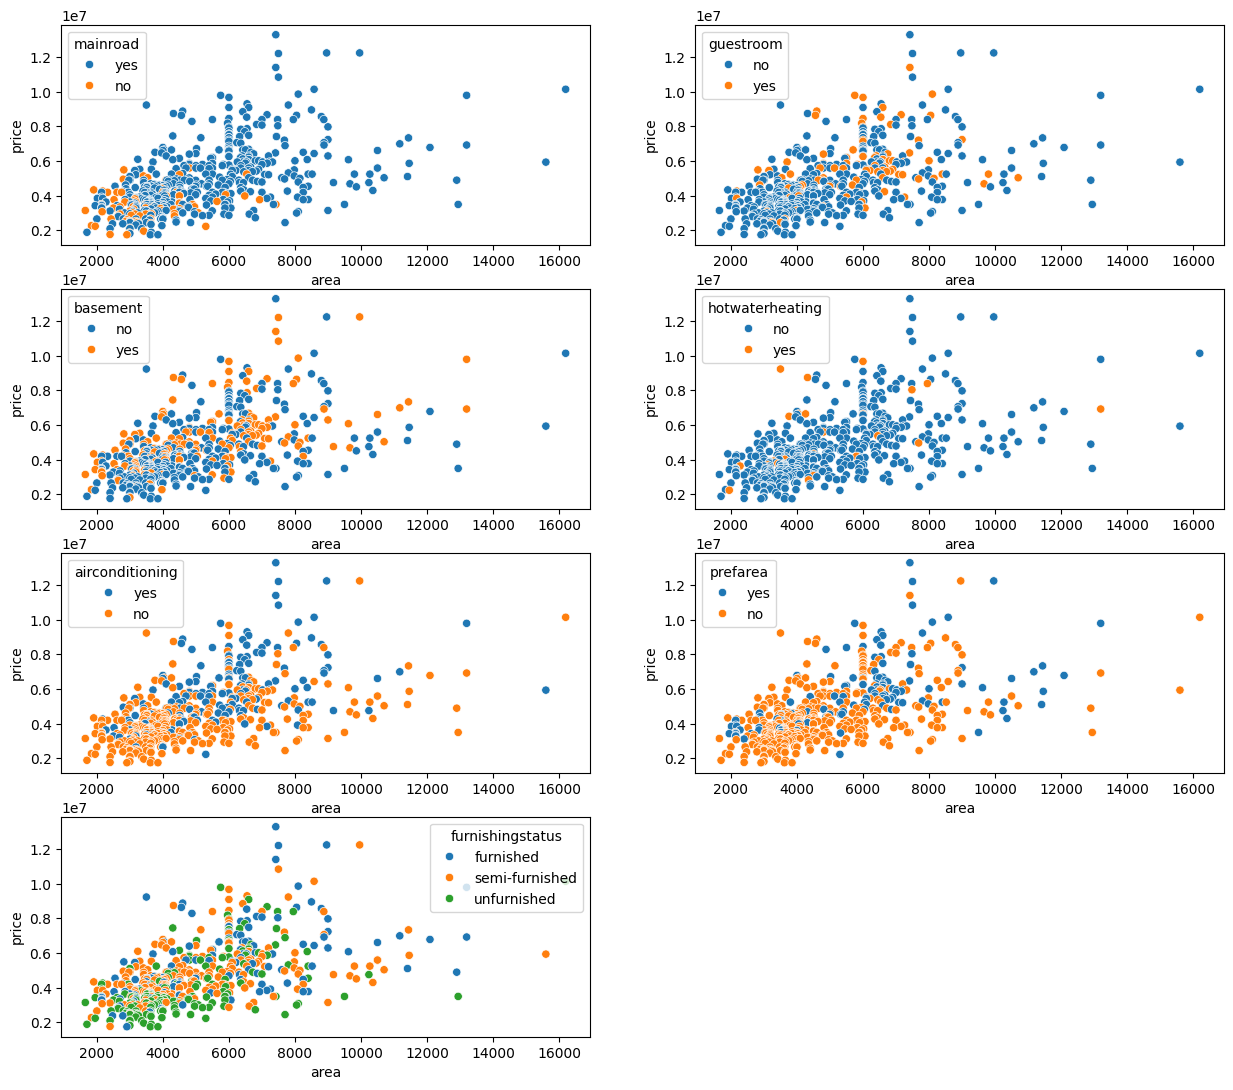

In [25]:
def scatter(column,fig_no):
    plt.subplot(6,2,fig_no)
    sns.scatterplot(
        x='area',
        y='price',
        hue=column,
        data=df
    )

plt.figure(figsize=(15,20))
for x in range(0, len(categorical)):
    scatter(categorical[x],x+1)

plt.show()